## ML Assignment 3 using the dataset Road Accident Dataset

In [1]:
# Loading the dataset

import pandas as pd

df = pd.read_csv('/home/bree/Downloads/ML Assignment 3/Road Accident  Data.csv')

print("Shape:", df.shape)
print(df.head())

Shape: (307973, 21)
  Accident_Index Accident Date Day_of_Week          Junction_Control  \
0      BS0000001    01-01-2021    Thursday  Give way or uncontrolled   
1      BS0000002    05-01-2021      Monday  Give way or uncontrolled   
2      BS0000003    04-01-2021      Sunday  Give way or uncontrolled   
3      BS0000004    05-01-2021      Monday       Auto traffic signal   
4      BS0000005    06-01-2021     Tuesday       Auto traffic signal   

           Junction_Detail Accident_Severity   Latitude  \
0  T or staggered junction           Serious  51.512273   
1               Crossroads           Serious  51.514399   
2  T or staggered junction            Slight  51.486668   
3  T or staggered junction           Serious  51.507804   
4               Crossroads           Serious  51.482076   

        Light_Conditions Local_Authority_(District) Carriageway_Hazards  ...  \
0               Daylight     Kensington and Chelsea                 NaN  ...   
1               Daylight     Ken

In [2]:
print(df.dtypes)

Accident_Index                 object
Accident Date                  object
Day_of_Week                    object
Junction_Control               object
Junction_Detail                object
Accident_Severity              object
Latitude                      float64
Light_Conditions               object
Local_Authority_(District)     object
Carriageway_Hazards            object
Longitude                     float64
Number_of_Casualties            int64
Number_of_Vehicles              int64
Police_Force                   object
Road_Surface_Conditions        object
Road_Type                      object
Speed_limit                     int64
Time                           object
Urban_or_Rural_Area            object
Weather_Conditions             object
Vehicle_Type                   object
dtype: object


In [3]:
# columns
print(df.columns)

Index(['Accident_Index', 'Accident Date', 'Day_of_Week', 'Junction_Control',
       'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Carriageway_Hazards', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time',
       'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type'],
      dtype='object')


In [4]:
# Missing values
print(df.isnull().sum())

Accident_Index                     0
Accident Date                      0
Day_of_Week                        0
Junction_Control                   0
Junction_Detail                    0
Accident_Severity                  0
Latitude                           0
Light_Conditions                   0
Local_Authority_(District)         0
Carriageway_Hazards           302549
Longitude                          0
Number_of_Casualties               0
Number_of_Vehicles                 0
Police_Force                       0
Road_Surface_Conditions            0
Road_Type                          0
Speed_limit                        0
Time                              17
Urban_or_Rural_Area                0
Weather_Conditions                 0
Vehicle_Type                       0
dtype: int64


### Data Cleaning

In [5]:
# Handling missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Removing duplicates
df.drop_duplicates(inplace=True)

df.drop(columns=['Accident_Index'], inplace=True)

# Encoding categorical variables
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

###For data cleaning, we handled missing values by filling them with median, removed duplicates, dropped the Accident_index column since   its not important in making predictions. We used LabelEncoder to convert the categorical String values into numerical values. LabelEncoder is simpler and more efficient compared to one-hot encoding which adds more columns to a dataset, increasing the number of features and risking overfitting and slowing the model's learning ability.

In [6]:
print(df.head())

   Accident Date  Day_of_Week  Junction_Control  Junction_Detail  \
0              0            4                 4                8   
1             96            1                 4                0   
2             72            3                 4                8   
3             96            1                 2                8   
4            120            5                 2                0   

   Accident_Severity   Latitude  Light_Conditions  Local_Authority_(District)  \
0                  2  51.512273                 4                         185   
1                  2  51.514399                 4                         185   
2                  3  51.486668                 4                         185   
3                  2  51.507804                 4                         185   
4                  2  51.482076                 1                         185   

   Carriageway_Hazards  Longitude  Number_of_Casualties  Number_of_Vehicles  \
0                    5  -

In [7]:
print(df.isnull().sum())

Accident Date                 0
Day_of_Week                   0
Junction_Control              0
Junction_Detail               0
Accident_Severity             0
Latitude                      0
Light_Conditions              0
Local_Authority_(District)    0
Carriageway_Hazards           0
Longitude                     0
Number_of_Casualties          0
Number_of_Vehicles            0
Police_Force                  0
Road_Surface_Conditions       0
Road_Type                     0
Speed_limit                   0
Time                          0
Urban_or_Rural_Area           0
Weather_Conditions            0
Vehicle_Type                  0
dtype: int64


### Exploratory Data Analysis

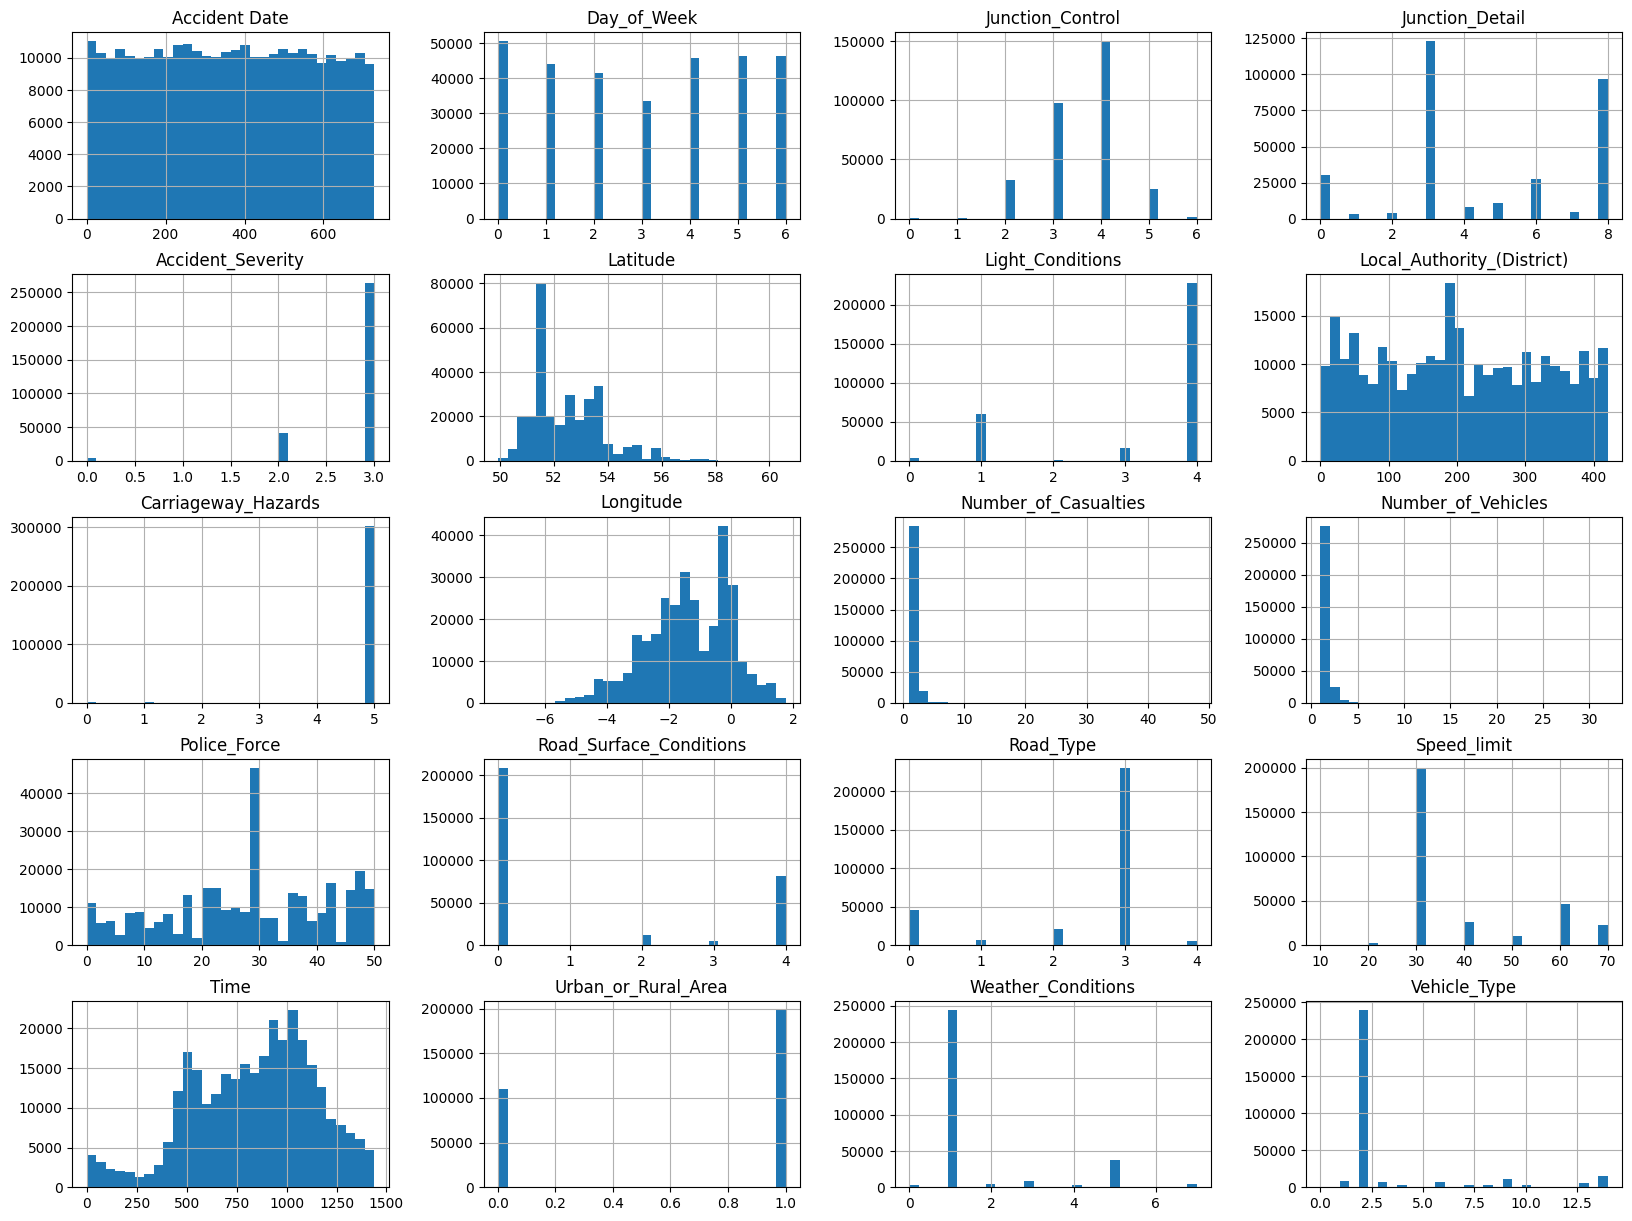

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms
df.hist(bins=30, figsize=(20,15))
plt.show()

### Histograms were used to visualize the distribution of numerical features in the dataset. 
 Each histogram shows how frequently different values appear for a specific feature, helping us identify patterns such as skewness, peaks
 and spread. For example, some features may be right-skewed, indicating that most values are clustered toward the lower range, 
 while others may be more uniformly distributed.

### Correlation Matrix

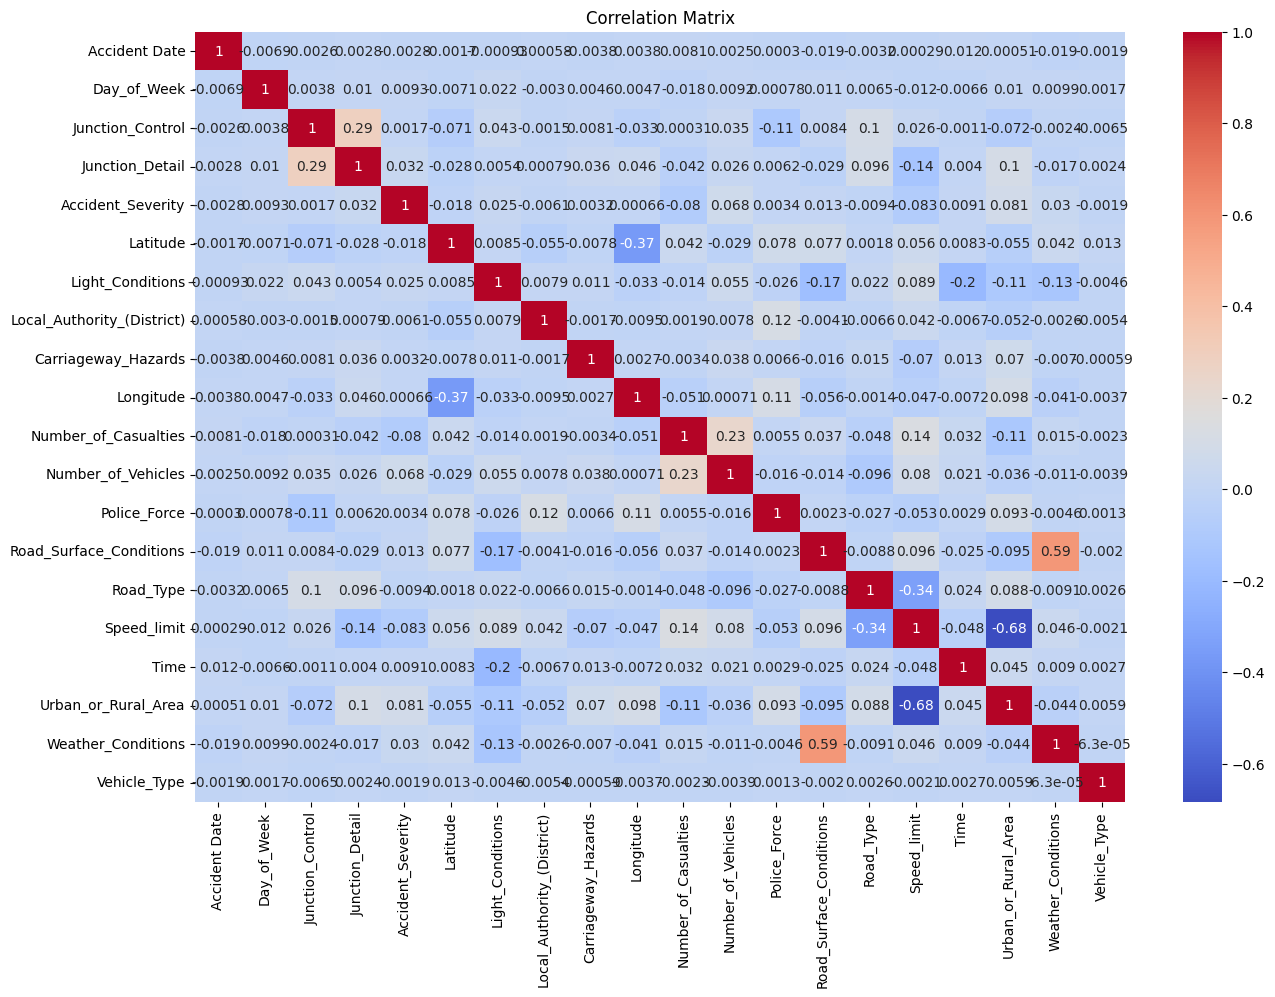

In [9]:
# Correlation
corr = df.corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### The correlation matrix displays how strongly features are related to each other using Pearson correlation coefficients.
This helps identify redundant features or detect important relationships between input variables and the target (Accident_Severity) 

### Outlier Detection via Boxplots

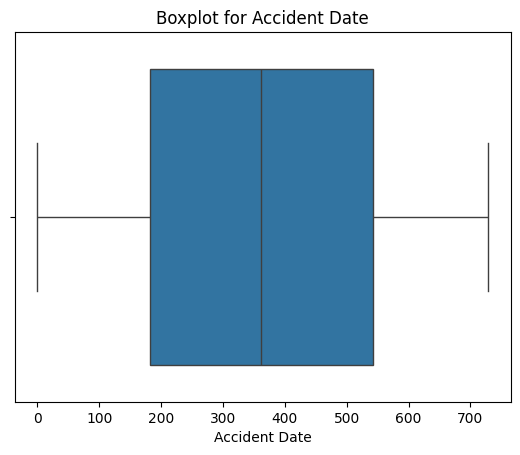

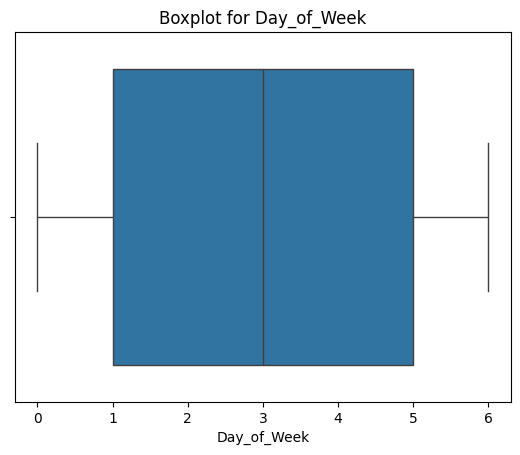

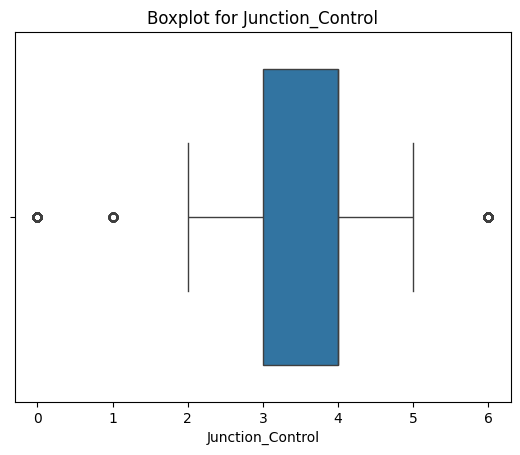

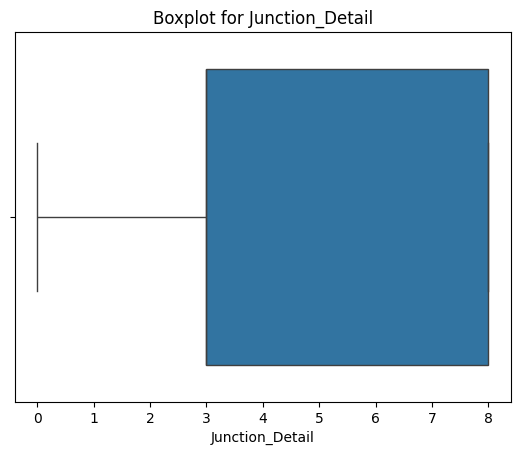

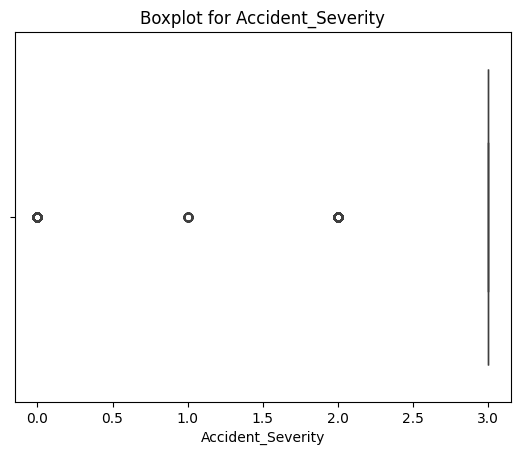

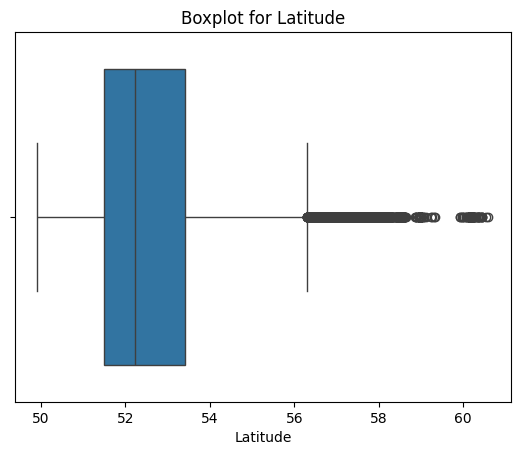

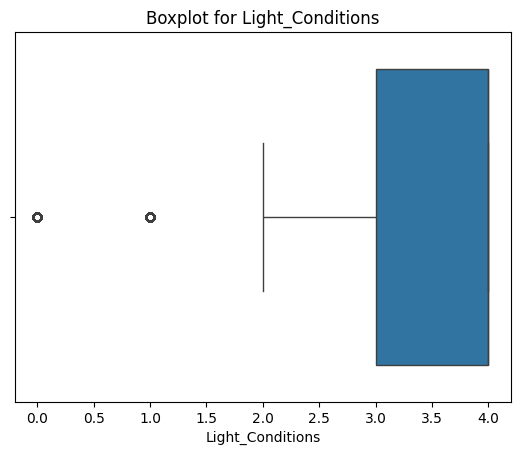

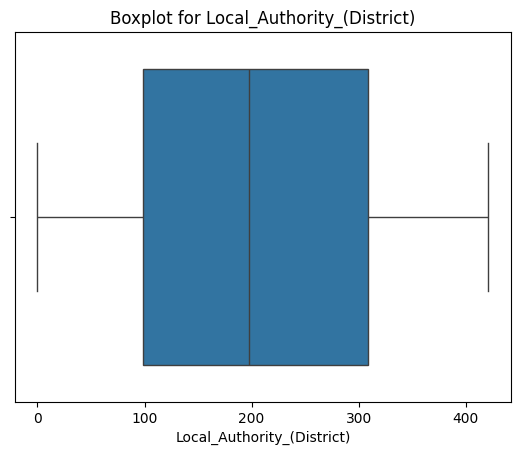

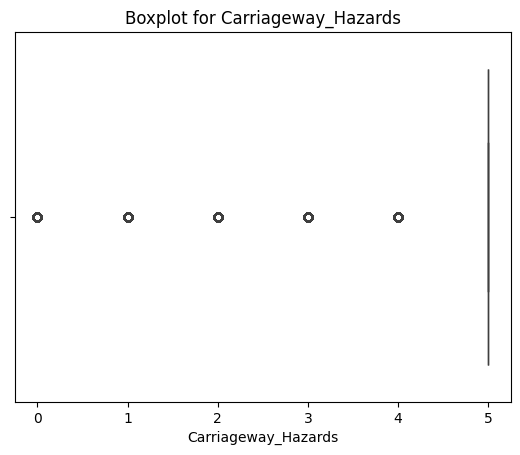

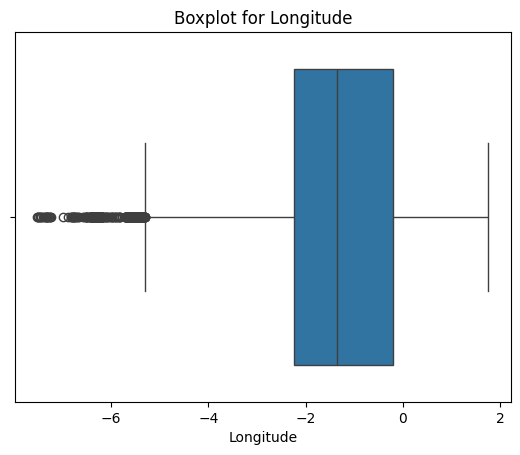

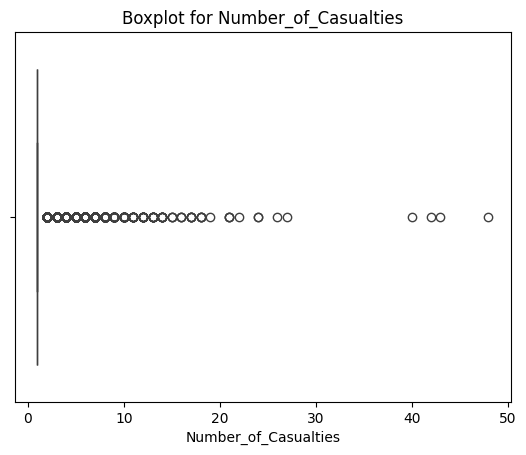

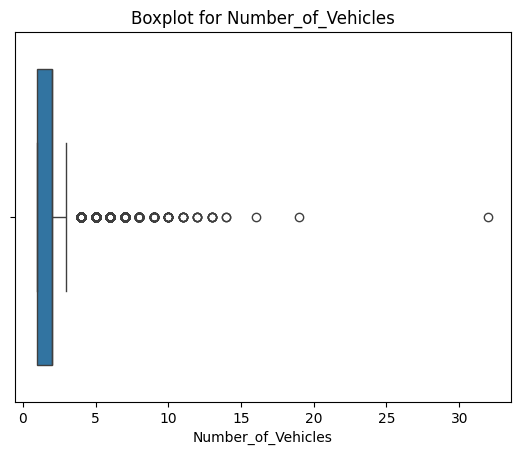

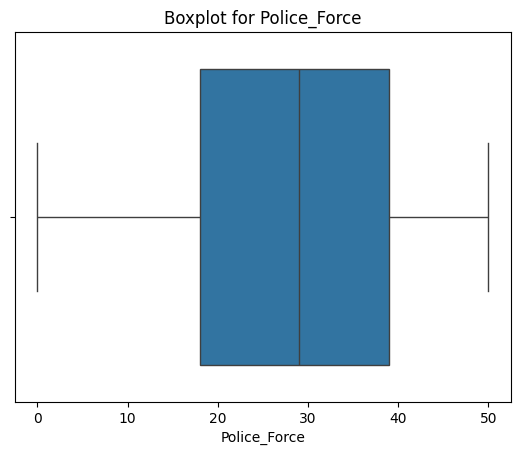

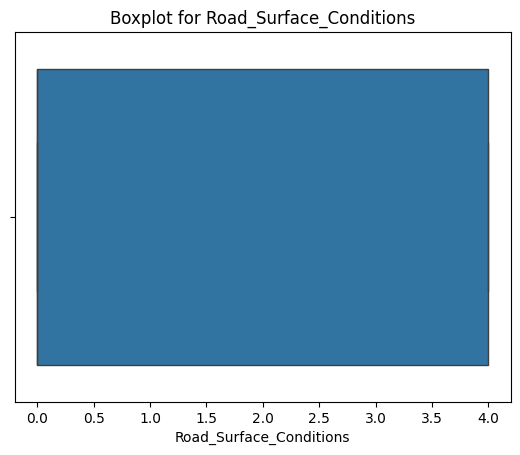

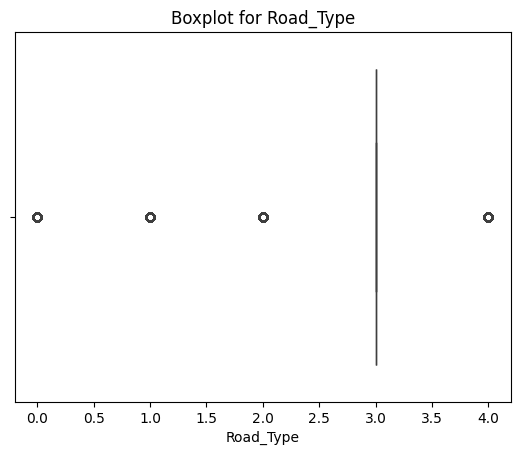

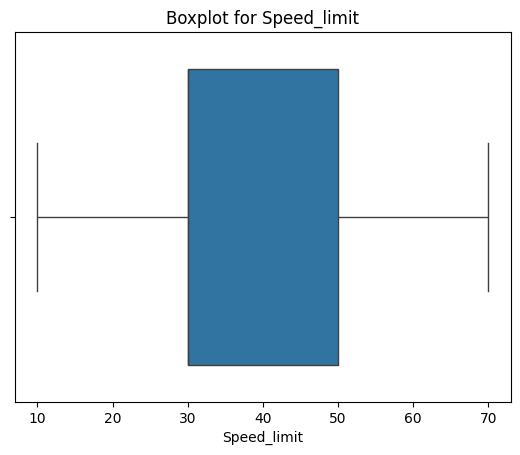

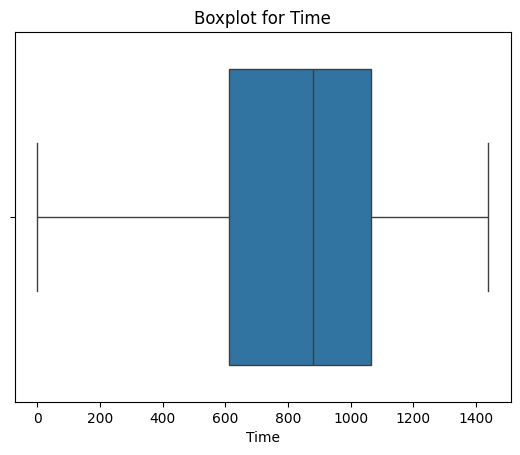

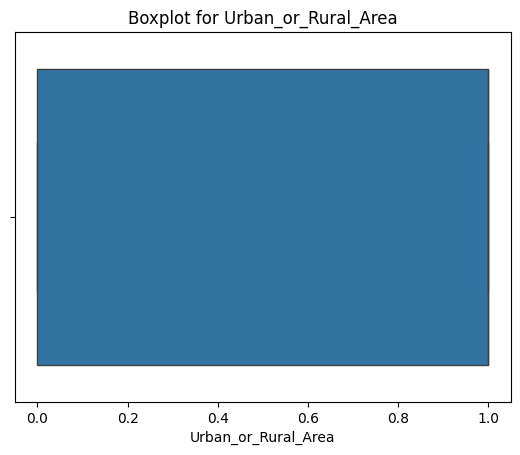

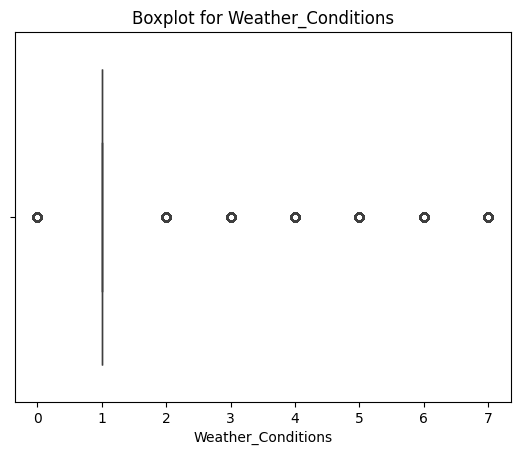

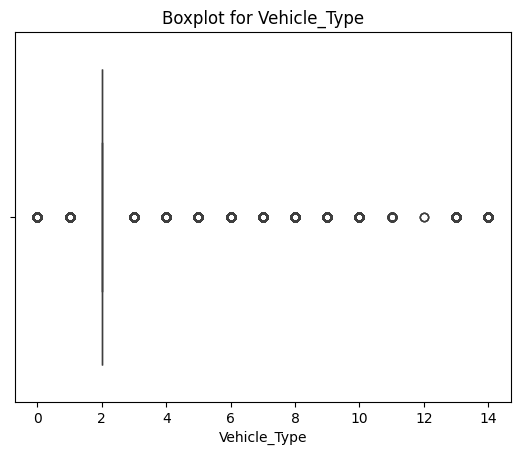

In [10]:
# Boxplot for outliers
for col in df.select_dtypes(include='number').columns:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot for {col}")
    plt.show()

### We used boxplots to identify outliers, data points that fall far outside the typical range for each numerical feature. 
These outliers appear as points that lie beyond the "whiskers" of the boxplot. 
Outliers can result from data entry errors, rare but real events, or natural variation. 
Identifying them is essential because some models are sensitive to extreme values, which can skew training results or reduce accuracy. 

### Feature Selection (Correlation & Tree-Based)

Top correlated features:
 Accident_Severity             1.000000
Urban_or_Rural_Area           0.081401
Number_of_Vehicles            0.068450
Junction_Detail               0.031618
Weather_Conditions            0.029797
Light_Conditions              0.025258
Road_Surface_Conditions       0.012613
Day_of_Week                   0.009287
Time                          0.009082
Police_Force                  0.003411
Carriageway_Hazards           0.003166
Junction_Control              0.001691
Longitude                     0.000664
Vehicle_Type                 -0.001899
Accident Date                -0.002787
Local_Authority_(District)   -0.006139
Road_Type                    -0.009431
Latitude                     -0.017743
Number_of_Casualties         -0.079812
Speed_limit                  -0.083084
Name: Accident_Severity, dtype: float64


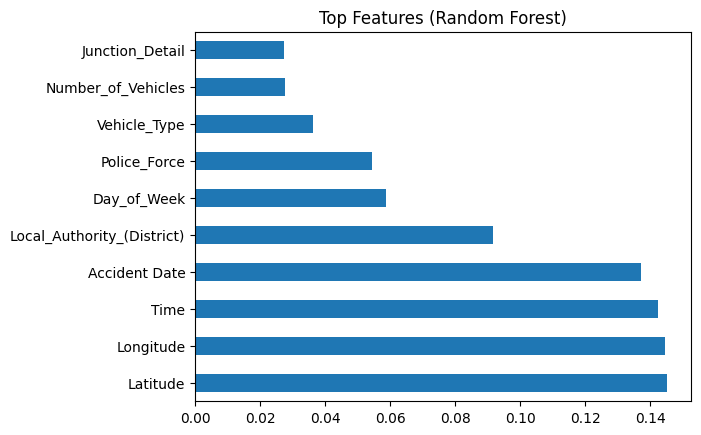

In [11]:
# 1. Correlation-based
correlation_target = corr["Accident_Severity"].sort_values(ascending=False)
print("Top correlated features:\n", correlation_target)

# 2. Tree-based feature importance
from sklearn.ensemble import RandomForestClassifier
X = df.drop("Accident_Severity", axis=1)
y = df["Accident_Severity"]

model = RandomForestClassifier()
model.fit(X, y)
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top Features (Random Forest)")
plt.show()

### In this step, we are performing feature selection, which means identifying which features (columns) in our dataset are most useful
 in predicting the target variable, Accident_Severity. We used two techniques: correlation-based ranking 
 and Random Forest feature importance. Feature selection is important because real-world datasets often contain features that 
 either add noise, are redundant or unnecessarily increase model complexity without boosting accuracy. By selecting only 
 the most relevant features, we aim to improve model performance, reduce training time and make our model more interpretable. 
 Correlation helps us measure how strongly each feature is linearly related to the target — a high positive or negative correlation 
 suggests that a feature has a significant influence on the outcome. On the other hand, Random Forest feature importance works by 
 training a Random Forest model and evaluating how much each feature contributes to reducing confusion in the decision-making process. 
 The more a feature improves the model's ability to split the data correctly, the higher its importance score.

##  Modelling
### Train-Test Split, SMOTE, Model Training


In [12]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler


# Scale your features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from imblearn.over_sampling import SMOTE

# Apply SMOTE before splitting
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Then split the resampled data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Neural Network": MLPClassifier(max_iter=1000)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "Classification Report": classification_report(y_test, y_pred, output_dict=True),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

    print(f"{name} Report:")
    print(classification_report(y_test, y_pred))
    print("\n")


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.50      0.57      0.53     52656
           1       0.80      0.95      0.87     52656
           2       0.41      0.26      0.32     52656
           3       0.46      0.47      0.47     52656

    accuracy                           0.56    210624
   macro avg       0.54      0.56      0.55    210624
weighted avg       0.54      0.56      0.55    210624



Decision Tree Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93     52656
           1       1.00      1.00      1.00     52656
           2       0.79      0.79      0.79     52656
           3       0.84      0.81      0.82     52656

    accuracy                           0.89    210624
   macro avg       0.89      0.89      0.89    210624
weighted avg       0.89      0.89      0.89    210624



Random Forest Report:
              precision    recall  f1-score   support


### K-Fold Cross-Validation

In [13]:
# from sklearn.model_selection import cross_val_score
# for name, model in models.items():
#     scores = cross_val_score(model, X, y, cv=5)
#     print(f"{name} CV Score: {scores.mean():.4f}")


/home/bree/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bree/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n

Logistic Regression CV Score: 0.4173
Decision Tree CV Score: 0.7532
Random Forest CV Score: 0.8539
Gradient Boosting CV Score: 0.7935
Neural Network CV Score: 0.8547


### We used 5-fold cross-validation to test how well each model performs on different parts of the data. 
 Instead of just splitting the data once into training and testing sets, cross-validation splits the data into 5 equal parts. 
 The model is trained on 4 parts and tested on the 1 left out — and this process repeats 5 times, with each part being used as the test set once.
 We then take the average of the 5 results. This helps us get a more accurate and fair idea of how the model will perform on new, unseen data.
 It also reduces the chance of overfitting and helps us compare models more confidently.

## Model Evaluation

In [14]:
# # Regression metrics

# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# mae = mean_absolute_error(y_test, y_pred)
# rmse = mean_squared_error(y_test, y_pred, squared=False)
# r2 = r2_score(y_test, y_pred)

# print("MAE =" , mae, "RMSE = ", rmse, "R-squared = " ,r2)

MAE = 0.4772580522637496 RMSE =  0.9812169825987215 R-squared =  0.22977058644788817


/home/bree/myenv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### we included some regression-style metrics (MAE, RMSE and R²) to give us extra insight into how close our model’s predictions are to the actual labels.
 MAE (Mean Absolute Error) tells us how far off our predictions are, on average.
 RMSE (Root Mean Squared Error) is similar but gives more weight to bigger errors.
 R² (R-squared) shows how much of the variation in the target variable the model explains — the closer to 1, the better.
 Even though these are usually used in regression problems, they can still give us a sense of how well the model’s numeric predictions match  the actual severity labels in this case.

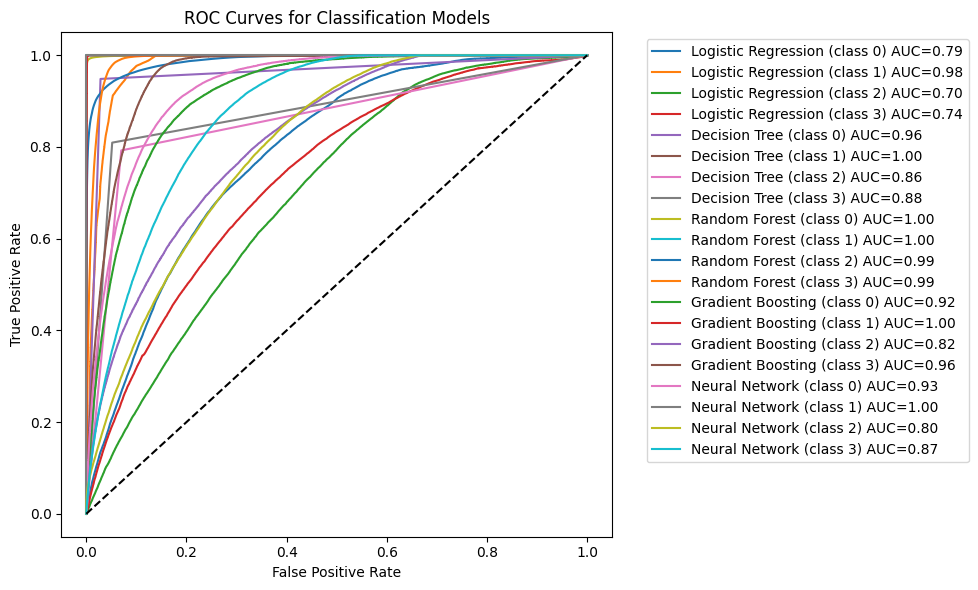

In [15]:
# ROC Curves

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize target for multi-class ROC
classes = sorted(list(set(y_test)))
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
        for i in range(len(classes)):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{name} (class {classes[i]}) AUC={roc_auc:.2f}")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Classification Models")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### We used ROC curves to evaluate how well each classification model separates the classes.
    For each model, we check how well it predicts the correct class at different thresholds. 
    The ROC curve shows the trade-off between the True Positive Rate and the False Positive Rate. 
    The closer the curve is to the top-left corner, the better the model performs. We also calculate the Area Under Curve score, 
    where a higher value (close to 1) means the model is doing a good job distinguishing between classes. 
    Since we have multiple classes in our data, we plot one ROC curve for each class and for each model to see how 
    they handle each severity level.

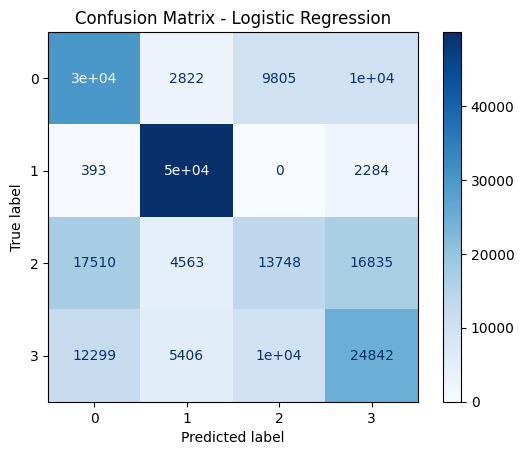

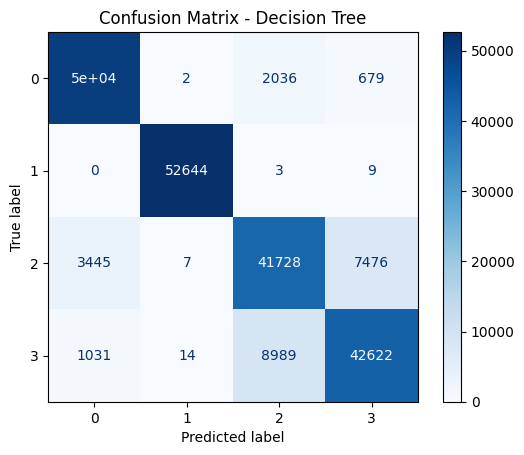

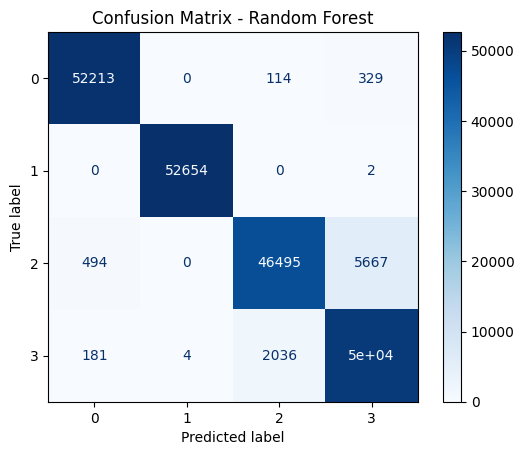

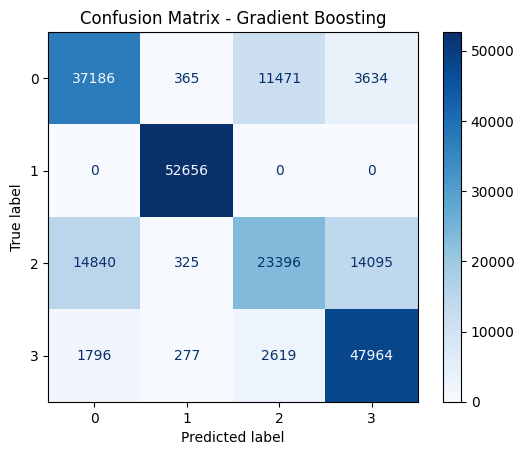

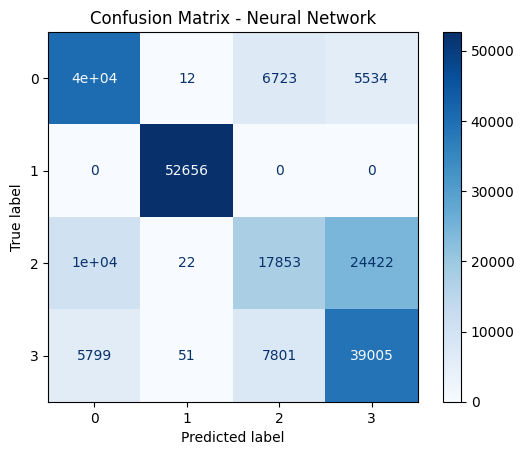

In [16]:
# confusion matrices

from sklearn.metrics import ConfusionMatrixDisplay

for name, model in models.items():
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


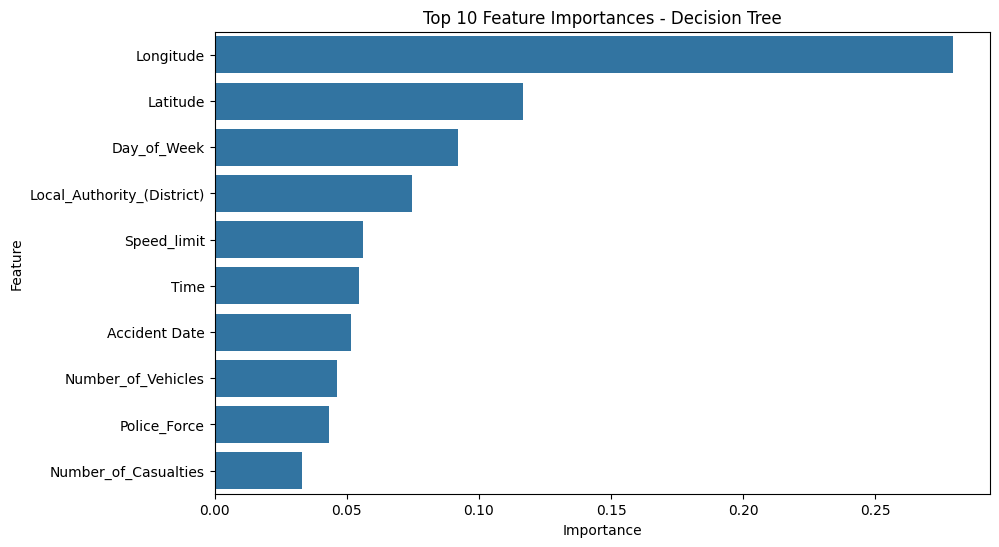

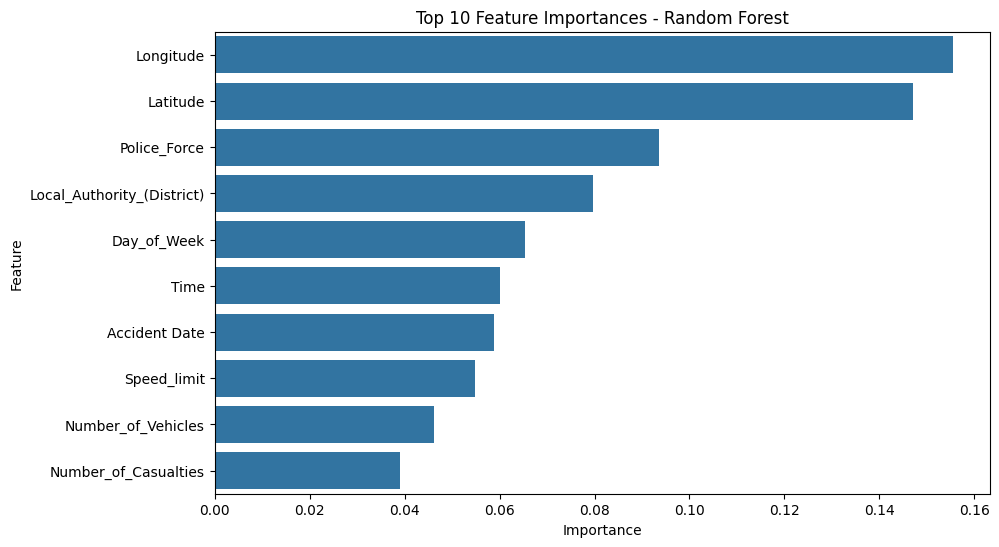

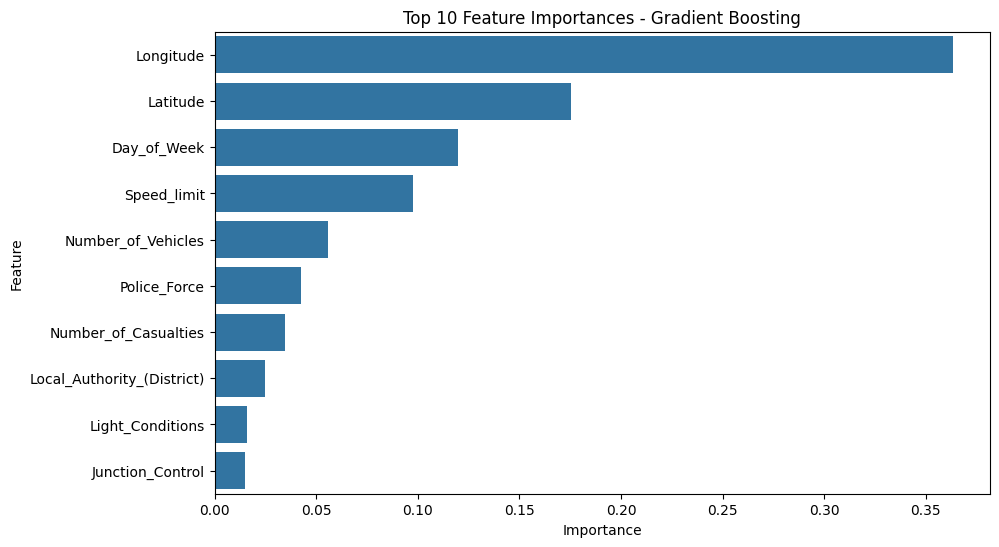

In [17]:
# Feature Importance Bar Charts

import pandas as pd
import seaborn as sns

for name, model in models.items():
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        feat_df = pd.DataFrame({
            'Feature': X.columns,
            'Importance': importance
        }).sort_values(by='Importance', ascending=False)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
        plt.title(f"Top 10 Feature Importances - {name}")
        plt.show()


In [18]:
# Model Comparison: Performance and Training Time

import time
from sklearn.metrics import f1_score

comparison = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    duration = time.time() - start

    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')

    comparison.append({
        "Model": name,
        "Training Time (s)": round(duration, 2),
        "Accuracy": model.score(X_test, y_test),
        "Weighted F1-score": f1
    })

comparison_df = pd.DataFrame(comparison).sort_values(by="Weighted F1-score", ascending=False)
print(comparison_df)


                 Model  Training Time (s)  Accuracy  Weighted F1-score
2        Random Forest             540.74  0.958020           0.957920
1        Decision Tree              42.05  0.887567           0.887111
3    Gradient Boosting            2458.61  0.765354           0.754755
4       Neural Network            1493.16  0.712564           0.705983
0  Logistic Regression              14.87  0.562761           0.545348


### Model Comparison
In this section, we compared the five classification models based on how long they take to train and how well they perform on the test data.
For each model, we measured the training time in seconds and calculated two performance metrics: accuracy and the weighted F1-score. 
Accuracy tells us the overall proportion of correct predictions, while 
the weighted F1-score gives a more balanced view by combining precision and recall, taking into account all the classes.
Although we balanced the dataset earlier using SMOTE, we still used the weighted F1-score because it helps evaluate how well 
the model performs across all severity levels, especially if minor imbalance remains or if certain models favor specific classes. 
All the results were stored in a table, and we sorted this table by the F1-score to identify which model gave the best overall performance.
This comparison helps us choose the most effective and efficient model for the road accident severity prediction task.
